In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
import matplotlib.pyplot as plt

# Enable Mixed Precision (faster training)
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

# =========================
# 2. Load Dataset
# =========================
data_dir = r"D:\SmartVision\DataSets\smartvision_dataset\classification"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

KeyboardInterrupt: 

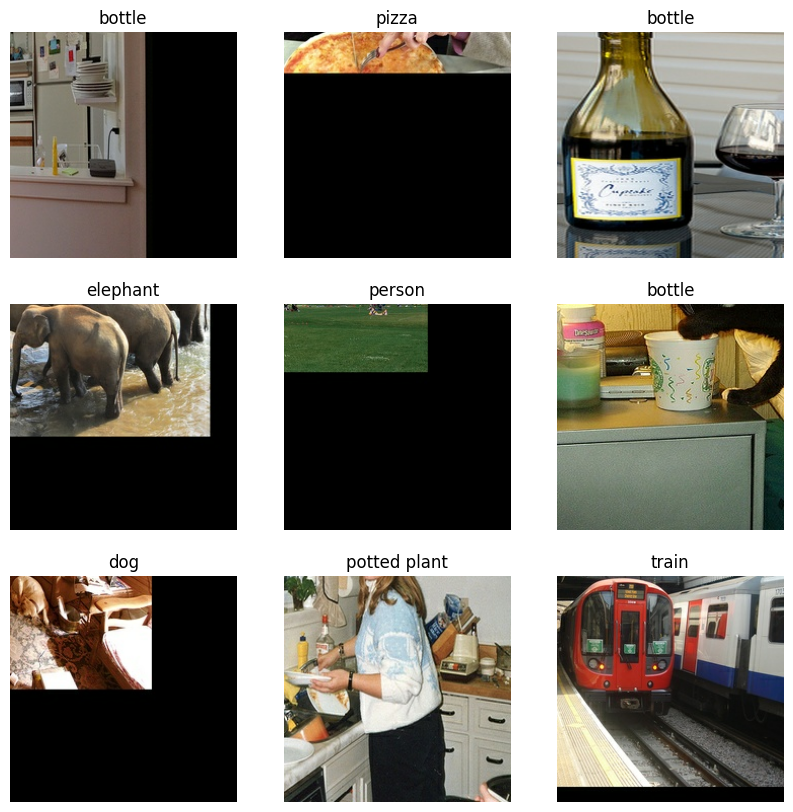

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.show()

In [ ]:
import os

for split in ['train','val','test']:
    print(f"\n{split.upper()}")
    path = f"D:/SmartVision/DataSets/smartvision_dataset/classification/{split}"
    for cls in os.listdir(path):
        print(cls, len(os.listdir(os.path.join(path, cls))))


TRAIN
airplane 70
bed 70
bench 70
bicycle 70
bird 70
bottle 70
bowl 70
bus 70
cake 70
car 70
cat 70
chair 70
couch 70
cow 70
cup 70
dog 70
elephant 70
horse 70
motorcycle 70
person 70
pizza 70
potted plant 70
stop sign 70
traffic light 70
train 70
truck 70

VAL
airplane 15
bed 15
bench 15
bicycle 15
bird 15
bottle 15
bowl 15
bus 15
cake 15
car 15
cat 15
chair 15
couch 15
cow 15
cup 15
dog 15
elephant 15
horse 15
motorcycle 15
person 15
pizza 15
potted plant 15
stop sign 15
traffic light 15
train 15
truck 15

TEST
airplane 15
bed 15
bench 15
bicycle 15
bird 15
bottle 15
bowl 15
bus 15
cake 15
car 15
cat 15
chair 15
couch 15
cow 15
cup 15
dog 15
elephant 15
horse 15
motorcycle 15
person 15
pizza 15
potted plant 15
stop sign 15
traffic light 15
train 15
truck 15


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# DATA
data_dir = r"D:\SmartVision\DataSets\smartvision_dataset\classification"

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/train",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/val",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir + "/test",
    image_size=(224,224),
    batch_size=32,
    label_mode="int"
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

# AUGMENTATION
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

train_ds = train_ds.map(lambda x,y: (augment(x, training=True), y))

# PREPROCESS
train_ds = train_ds.map(lambda x,y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x,y: (preprocess_input(x), y))
test_ds = test_ds.map(lambda x,y: (preprocess_input(x), y))

# PERFORMANCE
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

# MODEL
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.BatchNormalization()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=outputs)

# COMPILE
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# TRAIN
model.fit(train_ds, validation_data=val_ds, epochs=20)

# FINE-TUNE (IMPORTANT)
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.fit(train_ds, validation_data=val_ds, epochs=10)

# TEST
loss, acc = model.evaluate(test_ds)
print("🔥 Test Accuracy:", acc)

Found 1820 files belonging to 26 classes.
Found 390 files belonging to 26 classes.
Found 390 files belonging to 26 classes.
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 375s 4s/step - accuracy: 0.0582 - loss: 4.2037 - val_accuracy: 0.1077 - val_loss: 3.2551
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 315s 5s/step - accuracy: 0.1549 - loss: 3.3732 - val_accuracy: 0.2282 - val_loss: 2.9468
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.2538 - loss: 2.7085 - val_accuracy: 0.2487 - val_loss: 2.7018
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.3681 - loss: 2.2984 - val_accuracy: 0.2872 - val_loss: 2.5385
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.4379 - loss: 2.0025 - val_accuracy: 0.3513 - val_loss: 2.4310
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.5016 - loss: 1.7740 - val_accuracy: 0.3667 - val_loss: 2.3598
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5654 - loss: 1.5598 - val_accuracy: 0.4051 - val_lo